## Phase 3 : Architectures de Deep Learning

Tester 4 approches différentes (attention : 100 classes au lieu de 10!).

In [15]:
# Hyperparamètres communs:
import os
from tensorflow import keras
from tensorflow.keras import layers, callbacks

BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 100  # avec early stopping

os.makedirs("models", exist_ok=True)

# Callbacks obligatoires:
callback_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath="models/best_model_phase3.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
]

In [16]:
# Architecture 1 : CNN Personnalisé Simple

model_cnn_simple = keras.Sequential([
    layers.Conv2D(64, 3, activation="relu", padding="same", input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.30),

    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.40),

    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.50),
    layers.Dense(100, activation="softmax")  # 100 classes!
])

model_cnn_simple.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_cnn_simple.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,521,572 (9.62 MB)

 Trainable params: 2,520,676 (9.62 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Analyse d'image (code brut)
import numpy as np
import matplotlib.pyplot as plt

(_, _), (X_test, y_test) = keras.datasets.cifar100.load_data(label_mode="fine")

idx = 0
img_original = X_test[idx]
img_input = np.expand_dims(img_original.astype("float32") / 255.0, axis=0)
label_value = int(y_test[idx, 0])

# S'assurer que le modèle est bien initialisé
_ = model_cnn_simple(np.zeros((1, 32, 32, 3), dtype="float32"), training=False)

# Liste des couches convolutionnelles
conv_layers = [layer for layer in model_cnn_simple.layers if isinstance(layer, layers.Conv2D)]

print("Nombre de couches Conv2D:", len(conv_layers))
print("conv1:", conv_layers[0].name)
print("conv2:", conv_layers[1].name)
print("conv3:", conv_layers[2].name)

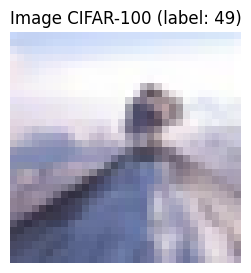

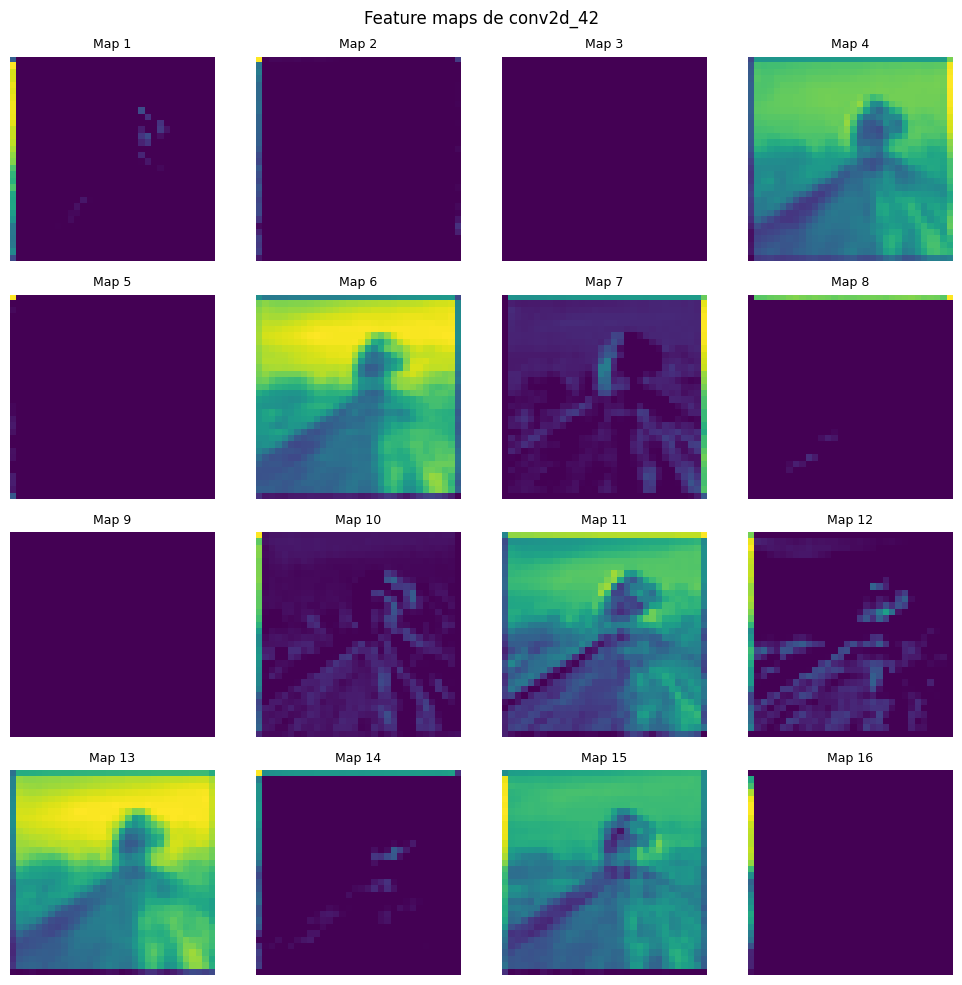

In [18]:
# Visualisation conv1 (code brut)
conv1_layer = conv_layers[0]
feature_extractor = keras.Model(inputs=model_cnn_simple.inputs, outputs=conv1_layer.output)
feature_maps = feature_extractor.predict(img_input, verbose=0)

plt.figure(figsize=(3, 3))
plt.imshow(img_original)
plt.title(f"Image CIFAR-100 (label: {label_value})")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
n_maps = min(16, feature_maps.shape[-1])

for i, ax in enumerate(axes.flat):
    if i < n_maps:
        ax.imshow(feature_maps[0, :, :, i], cmap="viridis")
        ax.set_title(f"Map {i+1}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Feature maps de {conv1_layer.name}")
plt.tight_layout()
plt.show()

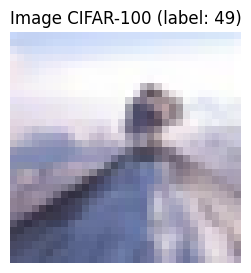

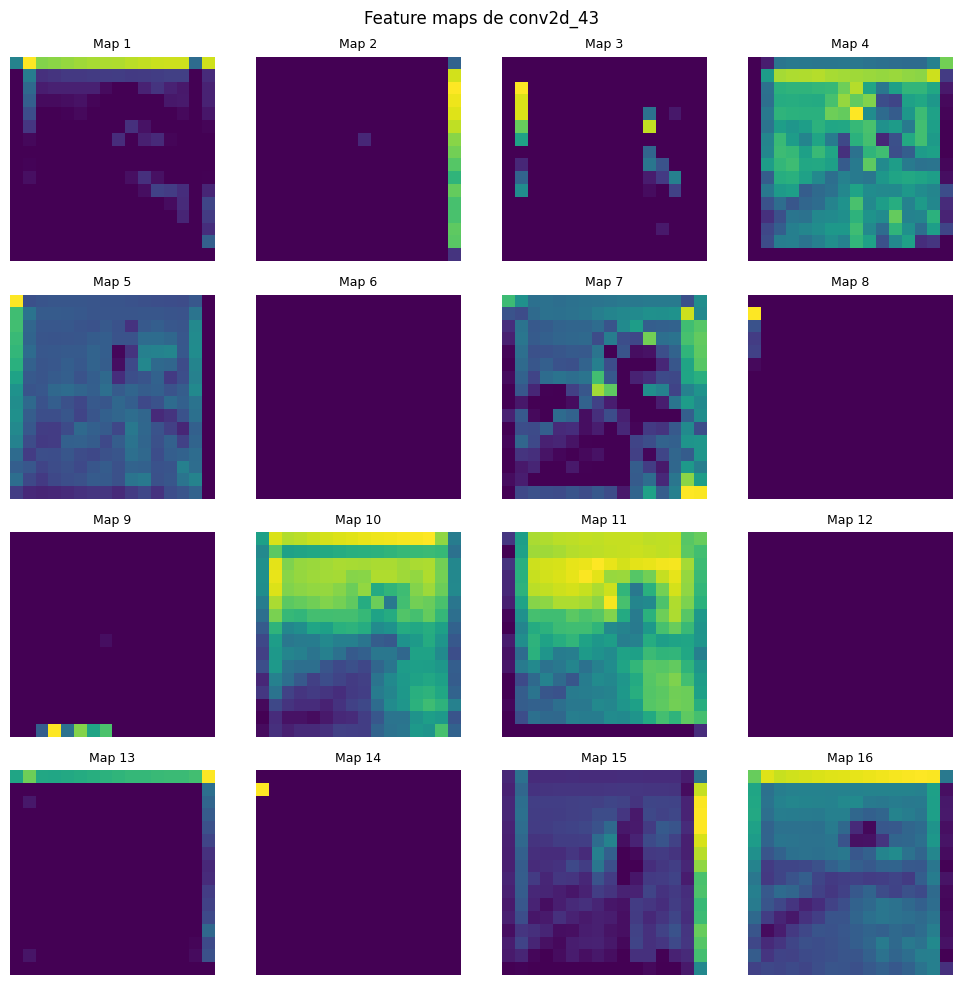

In [19]:
# Visualisation conv2 (code brut)
conv2_layer = conv_layers[1]
feature_extractor = keras.Model(inputs=model_cnn_simple.inputs, outputs=conv2_layer.output)
feature_maps = feature_extractor.predict(img_input, verbose=0)

plt.figure(figsize=(3, 3))
plt.imshow(img_original)
plt.title(f"Image CIFAR-100 (label: {label_value})")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
n_maps = min(16, feature_maps.shape[-1])

for i, ax in enumerate(axes.flat):
    if i < n_maps:
        ax.imshow(feature_maps[0, :, :, i], cmap="viridis")
        ax.set_title(f"Map {i+1}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Feature maps de {conv2_layer.name}")
plt.tight_layout()
plt.show()

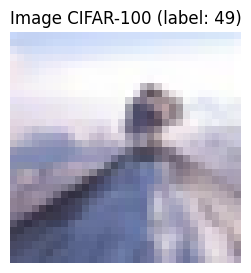

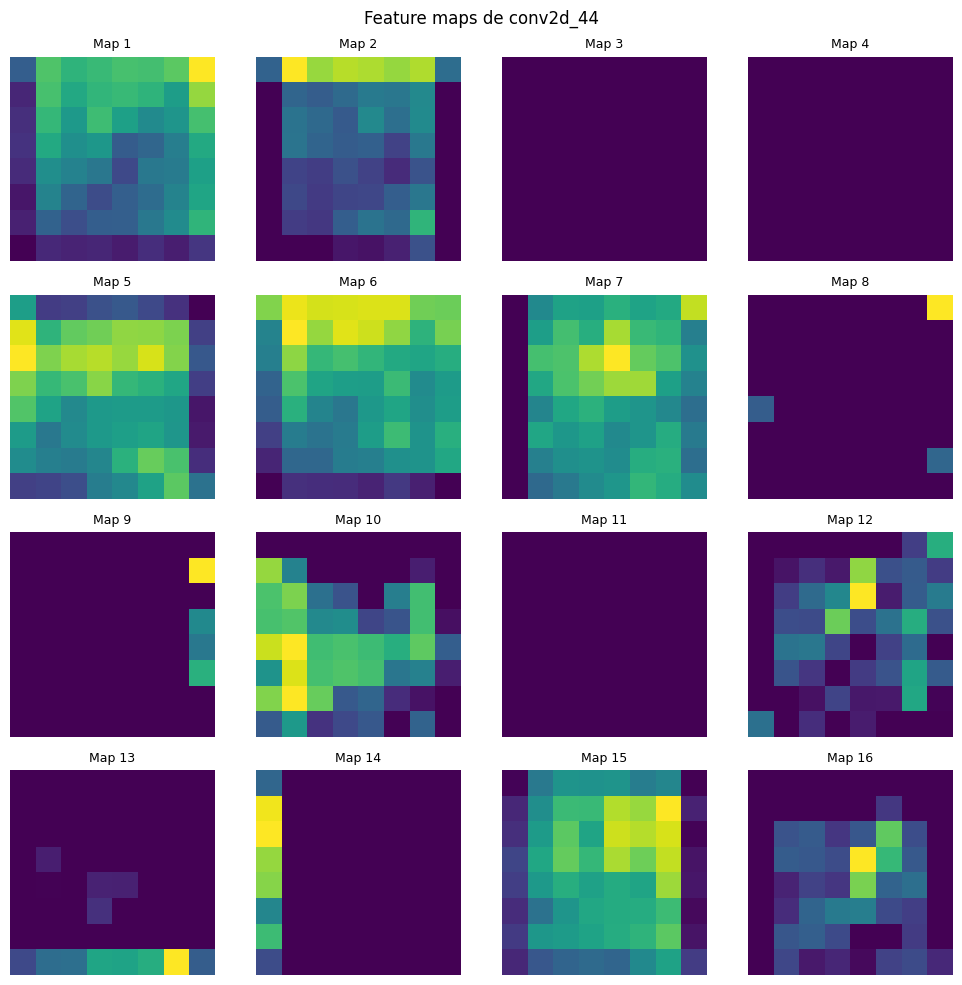

In [20]:
# Visualisation conv3 (code brut)
conv3_layer = conv_layers[2]
feature_extractor = keras.Model(inputs=model_cnn_simple.inputs, outputs=conv3_layer.output)
feature_maps = feature_extractor.predict(img_input, verbose=0)

plt.figure(figsize=(3, 3))
plt.imshow(img_original)
plt.title(f"Image CIFAR-100 (label: {label_value})")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
n_maps = min(16, feature_maps.shape[-1])

for i, ax in enumerate(axes.flat):
    if i < n_maps:
        ax.imshow(feature_maps[0, :, :, i], cmap="viridis")
        ax.set_title(f"Map {i+1}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Feature maps de {conv3_layer.name}")
plt.tight_layout()
plt.show()

In [21]:
# Architecture 2 : CNN Plus Profond (ResNet-like)
# Avec residual connections
# 6+ couches conv
# Skip connections tous les 2 blocs
# Batch normalization systématique


def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

inputs = keras.Input(shape=(32, 32, 3))

x = layers.Conv2D(64, 3, padding="same", use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = residual_block(x, 64)
x = residual_block(x, 64)

x = residual_block(x, 128, stride=2)
x = residual_block(x, 128)

x = residual_block(x, 256, stride=2)
x = residual_block(x, 256)

x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(100, activation="softmax")(x)

model_resnet_like = keras.Model(inputs, outputs, name="resnet_like_cifar100")

model_resnet_like.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_resnet_like.summary()

Model: "resnet_like_cifar100"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 32, 32,    │      1,728 │ input_layer_15[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_45[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_26[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_46[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_27[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_47[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_26[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 32, 32,    │          0 │ add_12[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_28[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_48[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_29       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_29[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_49[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 2,805,284 (10.70 MB)

 Trainable params: 2,800,804 (10.68 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [22]:
# Architecture 3 : Transfer Learning - MobileNetV2

# Upscale 32x32 → 96x96 ou 224x224 pour transfer learning
base_model_mobilenet = keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),  # ou (224, 224, 3)
    include_top=False,
    weights="imagenet",
)
base_model_mobilenet.trainable = False

model_mobilenet = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(96, 96),  # Redimensionner à l'entrée
    base_model_mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(100, activation="softmax")  # 100 classes!
])

model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_mobilenet.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_4 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,965,156 (11.31 MB)

 Trainable params: 707,172 (2.70 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
# Architecture 4 : Transfer Learning + Fine-tuning - EfficientNetB0

base_model_efficientnet = keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),  # Redimensionner CIFAR-100
    include_top=False,
    weights="imagenet",
)

# Fine-tuning : dégeler couches finales
base_model_efficientnet.trainable = True
for layer in base_model_efficientnet.layers[:-50]:  # Dégeler plus de couches
    layer.trainable = False

model_efficientnet = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(224, 224),  # Redimensionner à l'entrée
    base_model_efficientnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(100, activation="softmax")  # 100 classes!
])

model_efficientnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_efficientnet.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_5 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,756,743 (18.15 MB)

 Trainable params: 3,234,036 (12.34 MB)

 Non-trainable params: 1,522,707 (5.81 MB)

In [24]:
# Architecture 5 (Bonus) : Modèle Hiérarchique

# Prédire d'abord la super-classe (20), puis la classe fine (100)
# Deux branches de sortie
# Peut améliorer la performance en exploitant la hiérarchie
inputs = keras.Input(shape=(32, 32, 3))

x = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

super_output = layers.Dense(20, activation="softmax", name="super_output")(x)
fine_output = layers.Dense(100, activation="softmax", name="fine_output")(x)

model_hierarchical = keras.Model(
    inputs=inputs,
    outputs=[super_output, fine_output],
    name="hierarchical_cifar100",
)

model_hierarchical.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "super_output": "sparse_categorical_crossentropy",
        "fine_output": "sparse_categorical_crossentropy",
    },
    metrics={
        "super_output": ["accuracy"],
        "fine_output": ["accuracy"],
    },
)

model_hierarchical.summary()

Model: "hierarchical_cifar100"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input_layer_20[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ conv2d_60[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 8, 8, 128) │          0 │ conv2d_61[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_62[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 256)       │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ super_output        │ (None, 20)        │      5,140 │ dropout_20[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fine_output (Dense) │ (None, 100)       │     25,700 │ dropout_20[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 467,448 (1.78 MB)

 Trainable params: 467,448 (1.78 MB)

 Non-trainable params: 0 (0.00 B)